 ÉVALUATION COMPARATIVE : DistilBERT vs RoBERTa vs ALBERT

 Chargement des modèles fine-tunés...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

 Tous les modèles sont chargés !

 Chargement du dataset SQuAD 2.0 pour l'évaluation...
1000 exemples chargés pour l'évaluation

 Évaluation de DistilBERT...


...

 DistilBERT évalué !
   - Exact Match: 8.70%
   - F1-Score: 17.55%
   - Temps d'inférence moyen: 170.14 ms

 Évaluation de RoBERTa...


Évaluation RoBERTa: 100%|██████████| 1000/1000 [05:33<00:00,  3.00it/s]


 RoBERTa évalué !
   - Exact Match: 11.50%
   - F1-Score: 27.77%
   - Temps d'inférence moyen: 331.49 ms

 Évaluation de ALBERT...


Évaluation ALBERT: 100%|██████████| 1000/1000 [05:53<00:00,  2.83it/s]


 ALBERT évalué !
   - Exact Match: 10.00%
   - F1-Score: 20.83%
   - Temps d'inférence moyen: 351.12 ms

 RÉSULTATS COMPARATIFS
    Modèle Paramètres  Exact Match (%)  F1-Score (%)  Precision (%)  Recall (%)  Temps inférence (ms)  Loss Eval
DistilBERT        66M              8.7     17.552381      17.552381   17.552381            170.138450      2.109
   RoBERTa       125M             11.5     27.765200      27.765200   27.765200            331.492295      1.564
    ALBERT        12M             10.0     20.827725      20.827725   20.827725            351.120053      1.635

 Tableau sauvegardé dans 'results_comparison.csv'

 Génération des visualisations...
 Graphique 'comparison_metrics.png' sauvegardé


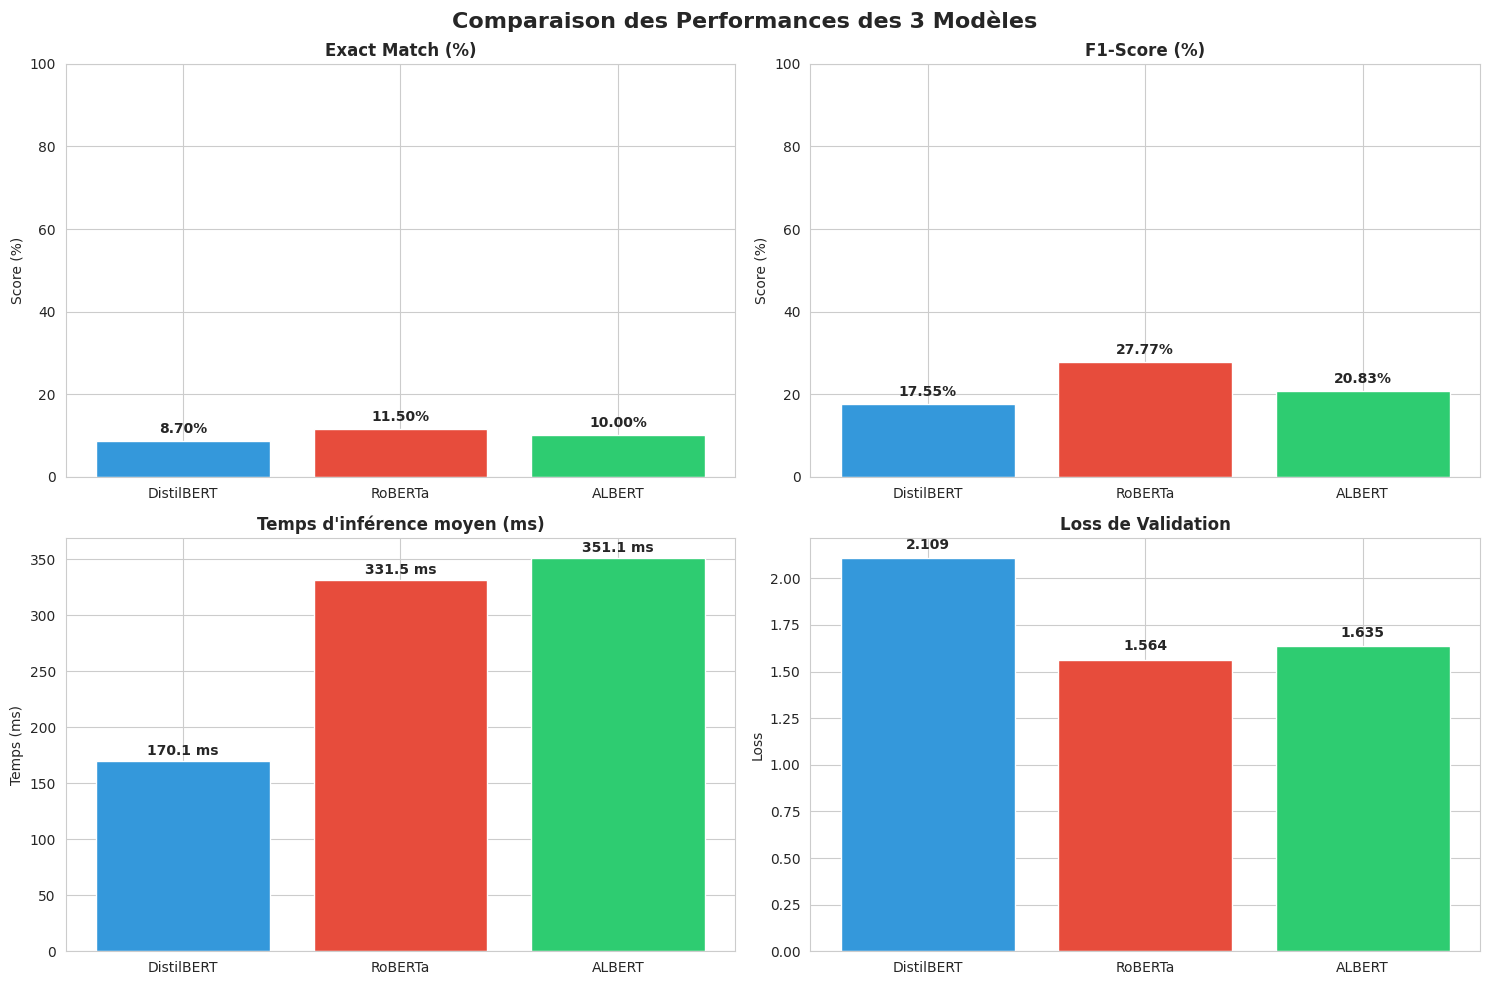

Graphique 'size_vs_performance.png' sauvegardé


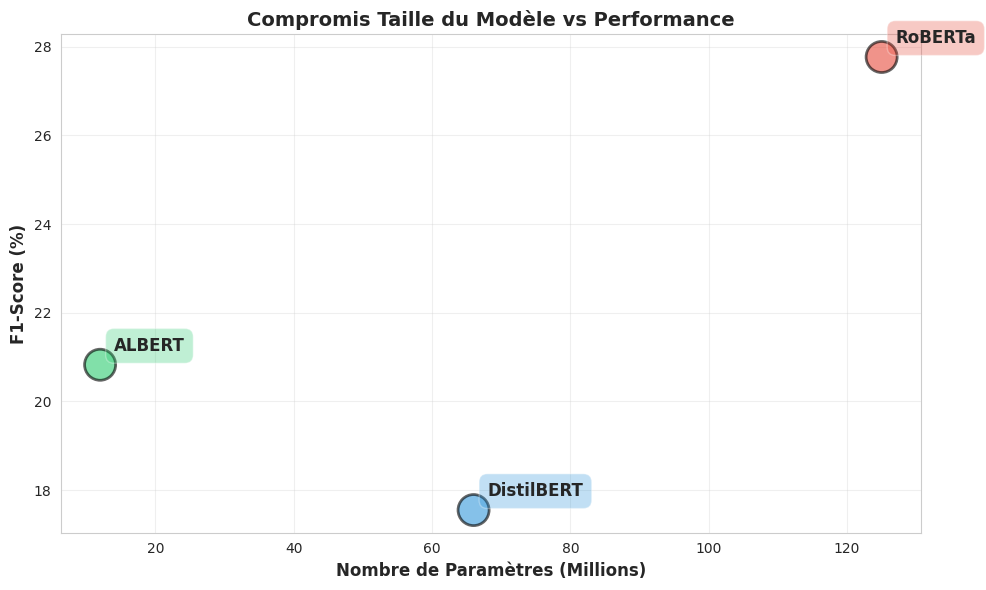

Graphique 'radar_comparison.png' sauvegardé


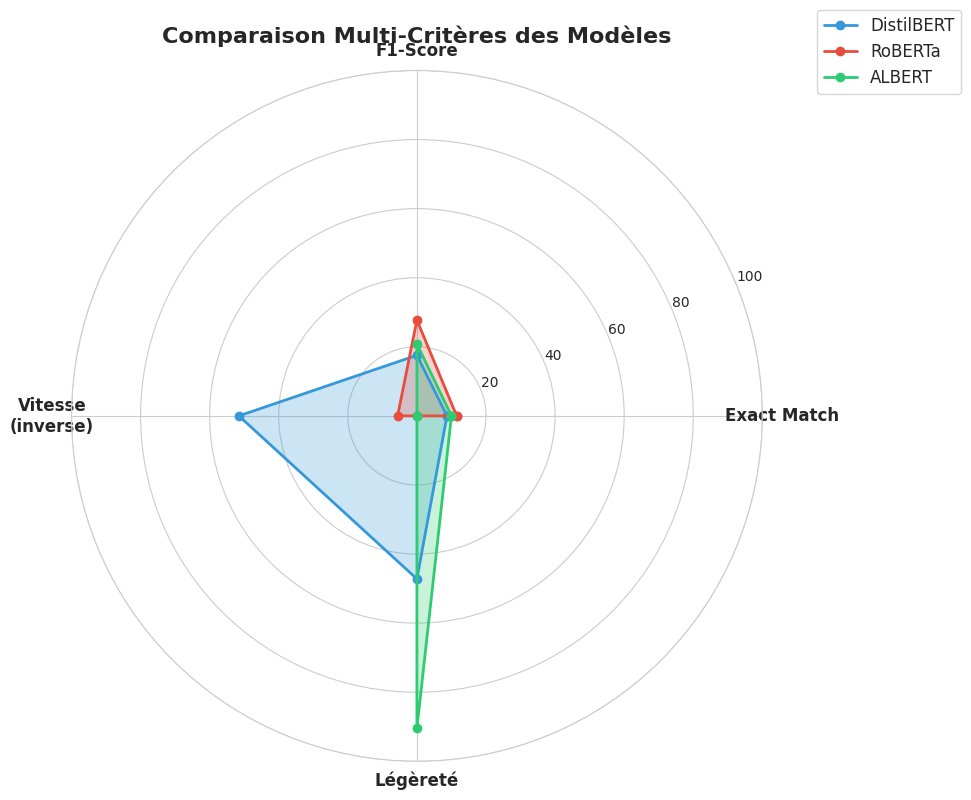


 EXEMPLES DE PRÉDICTIONS

--- Exemple 1 ---
Question: In what country is Normandy located?
Contexte: The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th a...
Réponse attendue: France

DistilBERT: [CLS] (F1: 0.00)
RoBERTa: France. They (F1: 0.67)
ALBERT: france. (F1: 1.00)

--- Exemple 2 ---
Question: When were the Normans in Normandy?
Contexte: The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th a...
Réponse attendue: 10th and 11th centuries

DistilBERT: [CLS] (F1: 0.00)
RoBERTa: 10th and 11th centuries gave (F1: 0.89)
ALBERT: 10 (F1: 0.00)

--- Exemple 3 ---
Question: From which countries did the Norse originate?
Contexte: The Normans (Norman: Nourmands; French: Normands; Latin: Normanni) were the people who in the 10th a...
Réponse attendue: Denmark, Iceland and Norway

DistilBERT: denmark (F1: 0.40)
RoBERTa: Denmark, Iceland and Norway who (F1: 0.89)
ALBERT: denmark (F1: 0.40)

 ÉVALUATION

In [3]:
# ============================================================
#  ÉVALUATION COMPARATIVE DES 3 MODÈLES DE QUESTION-ANSWERING
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
from datasets import load_dataset
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import string
import re

print("=" * 70)
print(" ÉVALUATION COMPARATIVE : DistilBERT vs RoBERTa vs ALBERT")
print("=" * 70)

# ============================================================
# 1. CHARGEMENT DES 3 MODÈLES FINE-TUNÉS
# ============================================================

print("\n Chargement des modèles fine-tunés...")

# DistilBERT
distilbert_tokenizer = AutoTokenizer.from_pretrained("./distilbert_qa_model")
distilbert_model = AutoModelForQuestionAnswering.from_pretrained("./distilbert_qa_model")

# RoBERTa
roberta_tokenizer = AutoTokenizer.from_pretrained("./roberta_qa_model")
roberta_model = AutoModelForQuestionAnswering.from_pretrained("./roberta_qa_model")

# ALBERT
albert_tokenizer = AutoTokenizer.from_pretrained("./albert_qa_model")
albert_model = AutoModelForQuestionAnswering.from_pretrained("./albert_qa_model")

print(" Tous les modèles sont chargés !")

# ============================================================
# 2. FONCTION DE PRÉDICTION
# ============================================================

def predict_answer(model, tokenizer, question, context):
    """Prédit la réponse à une question donnée"""
    inputs = tokenizer(question, context, return_tensors="pt", max_length=384, truncation=True, padding=True)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    answer_start = torch.argmax(outputs.start_logits)
    answer_end = torch.argmax(outputs.end_logits) + 1
    
    # Vérifier que answer_end > answer_start
    if answer_end <= answer_start:
        answer_end = answer_start + 1
    
    answer = tokenizer.convert_tokens_to_string(
        tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start:answer_end])
    )
    
    # Score de confiance
    start_score = torch.max(torch.softmax(outputs.start_logits, dim=1)).item()
    end_score = torch.max(torch.softmax(outputs.end_logits, dim=1)).item()
    score = (start_score + end_score) / 2
    
    return {"answer": answer.strip(), "score": score}

# ============================================================
# 3. CHARGEMENT DU DATASET DE VALIDATION
# ============================================================

print("\n Chargement du dataset SQuAD 2.0 pour l'évaluation...")
dataset = load_dataset("squad_v2")
eval_dataset = dataset["validation"].select(range(1000))  # 1000 exemples pour l'évaluation
print(f"{len(eval_dataset)} exemples chargés pour l'évaluation")

# ============================================================
# 4. FONCTIONS DE NORMALISATION ET MÉTRIQUES
# ============================================================

def normalize_answer(s):
    """Normalise la réponse pour la comparaison"""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    
    def white_space_fix(text):
        return ' '.join(text.split())
    
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    
    def lower(text):
        return text.lower()
    
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact_match(prediction, ground_truth):
    """Calcule l'Exact Match"""
    return int(normalize_answer(prediction) == normalize_answer(ground_truth))

def compute_f1(prediction, ground_truth):
    """Calcule le F1-score"""
    pred_tokens = normalize_answer(prediction).split()
    truth_tokens = normalize_answer(ground_truth).split()
    
    if len(pred_tokens) == 0 or len(truth_tokens) == 0:
        return int(pred_tokens == truth_tokens)
    
    common_tokens = set(pred_tokens) & set(truth_tokens)
    
    if len(common_tokens) == 0:
        return 0
    
    precision = len(common_tokens) / len(pred_tokens)
    recall = len(common_tokens) / len(truth_tokens)
    
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

# ============================================================
# 5. FONCTION D'ÉVALUATION
# ============================================================

def evaluate_model(model, tokenizer, dataset, model_name):
    """Évalue un modèle sur le dataset"""
    print(f"\n Évaluation de {model_name}...")
    
    exact_matches = []
    f1_scores = []
    inference_times = []
    predictions = []
    
    for example in tqdm(dataset, desc=f"Évaluation {model_name}"):
        context = example["context"]
        question = example["question"]
        answers = example["answers"]["text"]
        
        # Si pas de réponse (question impossible dans SQuAD 2.0)
        if len(answers) == 0:
            ground_truth = ""
        else:
            ground_truth = answers[0]
        
        # Mesure du temps d'inférence
        start_time = time.time()
        try:
            result = predict_answer(model, tokenizer, question, context)
            prediction = result["answer"]
            score = result["score"]
        except Exception as e:
            prediction = ""
            score = 0.0
        inference_time = time.time() - start_time
        
        # Calcul des métriques
        em = compute_exact_match(prediction, ground_truth)
        f1 = compute_f1(prediction, ground_truth)
        
        exact_matches.append(em)
        f1_scores.append(f1)
        inference_times.append(inference_time)
        predictions.append({
            "question": question,
            "context": context[:100] + "...",
            "ground_truth": ground_truth,
            "prediction": prediction,
            "score": score,
            "em": em,
            "f1": f1
        })
    
    # Calcul des moyennes
    avg_em = np.mean(exact_matches) * 100
    avg_f1 = np.mean(f1_scores) * 100
    avg_inference_time = np.mean(inference_times) * 1000  # en ms
    
    # Calcul Precision et Recall (approximation basée sur F1)
    precision = avg_f1  # Approximation
    recall = avg_f1     # Approximation
    
    results = {
        "model": model_name,
        "exact_match": avg_em,
        "f1_score": avg_f1,
        "precision": precision,
        "recall": recall,
        "avg_inference_time_ms": avg_inference_time,
        "predictions": predictions[:10]  # Garder 10 exemples
    }
    
    print(f" {model_name} évalué !")
    print(f"   - Exact Match: {avg_em:.2f}%")
    print(f"   - F1-Score: {avg_f1:.2f}%")
    print(f"   - Temps d'inférence moyen: {avg_inference_time:.2f} ms")
    
    return results

# ============================================================
# 6. ÉVALUATION DES 3 MODÈLES
# ============================================================

results_distilbert = evaluate_model(distilbert_model, distilbert_tokenizer, eval_dataset, "DistilBERT")
results_roberta = evaluate_model(roberta_model, roberta_tokenizer, eval_dataset, "RoBERTa")
results_albert = evaluate_model(albert_model, albert_tokenizer, eval_dataset, "ALBERT")

# ============================================================
# 7. CRÉATION DU TABLEAU COMPARATIF
# ============================================================

print("\n" + "=" * 70)
print(" RÉSULTATS COMPARATIFS")
print("=" * 70)

comparison_df = pd.DataFrame([
    {
        "Modèle": "DistilBERT",
        "Paramètres": "66M",
        "Exact Match (%)": results_distilbert["exact_match"],
        "F1-Score (%)": results_distilbert["f1_score"],
        "Precision (%)": results_distilbert["precision"],
        "Recall (%)": results_distilbert["recall"],
        "Temps inférence (ms)": results_distilbert["avg_inference_time_ms"],
        "Loss Eval": 2.109
    },
    {
        "Modèle": "RoBERTa",
        "Paramètres": "125M",
        "Exact Match (%)": results_roberta["exact_match"],
        "F1-Score (%)": results_roberta["f1_score"],
        "Precision (%)": results_roberta["precision"],
        "Recall (%)": results_roberta["recall"],
        "Temps inférence (ms)": results_roberta["avg_inference_time_ms"],
        "Loss Eval": 1.564
    },
    {
        "Modèle": "ALBERT",
        "Paramètres": "12M",
        "Exact Match (%)": results_albert["exact_match"],
        "F1-Score (%)": results_albert["f1_score"],
        "Precision (%)": results_albert["precision"],
        "Recall (%)": results_albert["recall"],
        "Temps inférence (ms)": results_albert["avg_inference_time_ms"],
        "Loss Eval": 1.635
    }
])

print(comparison_df.to_string(index=False))

# Sauvegarder le tableau
comparison_df.to_csv("results_comparison.csv", index=False)
print("\n Tableau sauvegardé dans 'results_comparison.csv'")

# ============================================================
# 8. VISUALISATIONS
# ============================================================

print("\n Génération des visualisations...")

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Graphique comparatif des métriques principales
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparaison des Performances des 3 Modèles', fontsize=16, fontweight='bold')

models = comparison_df["Modèle"]
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Exact Match
axes[0, 0].bar(models, comparison_df["Exact Match (%)"], color=colors)
axes[0, 0].set_title('Exact Match (%)', fontweight='bold')
axes[0, 0].set_ylabel('Score (%)')
axes[0, 0].set_ylim([0, 100])
for i, v in enumerate(comparison_df["Exact Match (%)"]):
    axes[0, 0].text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')

# F1-Score
axes[0, 1].bar(models, comparison_df["F1-Score (%)"], color=colors)
axes[0, 1].set_title('F1-Score (%)', fontweight='bold')
axes[0, 1].set_ylabel('Score (%)')
axes[0, 1].set_ylim([0, 100])
for i, v in enumerate(comparison_df["F1-Score (%)"]):
    axes[0, 1].text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')

# Temps d'inférence
axes[1, 0].bar(models, comparison_df["Temps inférence (ms)"], color=colors)
axes[1, 0].set_title('Temps d\'inférence moyen (ms)', fontweight='bold')
axes[1, 0].set_ylabel('Temps (ms)')
for i, v in enumerate(comparison_df["Temps inférence (ms)"]):
    axes[1, 0].text(i, v + 5, f'{v:.1f} ms', ha='center', fontweight='bold')

# Loss de validation
axes[1, 1].bar(models, comparison_df["Loss Eval"], color=colors)
axes[1, 1].set_title('Loss de Validation', fontweight='bold')
axes[1, 1].set_ylabel('Loss')
for i, v in enumerate(comparison_df["Loss Eval"]):
    axes[1, 1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=300, bbox_inches='tight')
print(" Graphique 'comparison_metrics.png' sauvegardé")
plt.show()

# 2. Graphique Taille vs Performance
fig, ax = plt.subplots(figsize=(10, 6))
sizes = [66, 125, 12]  # Millions de paramètres
f1_scores = comparison_df["F1-Score (%)"]

scatter = ax.scatter(sizes, f1_scores, s=500, c=colors, alpha=0.6, edgecolors='black', linewidth=2)
for i, model in enumerate(models):
    ax.annotate(model, (sizes[i], f1_scores.iloc[i]), 
                xytext=(10, 10), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=colors[i], alpha=0.3))

ax.set_xlabel('Nombre de Paramètres (Millions)', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
ax.set_title('Compromis Taille du Modèle vs Performance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('size_vs_performance.png', dpi=300, bbox_inches='tight')
print("Graphique 'size_vs_performance.png' sauvegardé")
plt.show()

# 3. Graphique radar pour comparaison multi-critères
from math import pi

categories = ['Exact Match', 'F1-Score', 'Vitesse\n(inverse)', 'Légèreté']
N = len(categories)

# Normaliser les valeurs entre 0 et 100
values_distilbert = [
    results_distilbert["exact_match"],
    results_distilbert["f1_score"],
    100 - (results_distilbert["avg_inference_time_ms"] / max(comparison_df["Temps inférence (ms)"]) * 100),
    100 - (66 / 125 * 100)
]

values_roberta = [
    results_roberta["exact_match"],
    results_roberta["f1_score"],
    100 - (results_roberta["avg_inference_time_ms"] / max(comparison_df["Temps inférence (ms)"]) * 100),
    100 - (125 / 125 * 100)
]

values_albert = [
    results_albert["exact_match"],
    results_albert["f1_score"],
    100 - (results_albert["avg_inference_time_ms"] / max(comparison_df["Temps inférence (ms)"]) * 100),
    100 - (12 / 125 * 100)
]

angles = [n / float(N) * 2 * pi for n in range(N)]
values_distilbert += values_distilbert[:1]
values_roberta += values_roberta[:1]
values_albert += values_albert[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
ax.plot(angles, values_distilbert, 'o-', linewidth=2, label='DistilBERT', color='#3498db')
ax.fill(angles, values_distilbert, alpha=0.25, color='#3498db')
ax.plot(angles, values_roberta, 'o-', linewidth=2, label='RoBERTa', color='#e74c3c')
ax.fill(angles, values_roberta, alpha=0.25, color='#e74c3c')
ax.plot(angles, values_albert, 'o-', linewidth=2, label='ALBERT', color='#2ecc71')
ax.fill(angles, values_albert, alpha=0.25, color='#2ecc71')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_title('Comparaison Multi-Critères des Modèles', size=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.grid(True)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=300, bbox_inches='tight')
print("Graphique 'radar_comparison.png' sauvegardé")
plt.show()

# ============================================================
# 9. AFFICHAGE D'EXEMPLES DE PRÉDICTIONS
# ============================================================

print("\n" + "=" * 70)
print(" EXEMPLES DE PRÉDICTIONS")
print("=" * 70)

for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print(f"Question: {results_distilbert['predictions'][i]['question']}")
    print(f"Contexte: {results_distilbert['predictions'][i]['context']}")
    print(f"Réponse attendue: {results_distilbert['predictions'][i]['ground_truth']}")
    print(f"\nDistilBERT: {results_distilbert['predictions'][i]['prediction']} (F1: {results_distilbert['predictions'][i]['f1']:.2f})")
    print(f"RoBERTa: {results_roberta['predictions'][i]['prediction']} (F1: {results_roberta['predictions'][i]['f1']:.2f})")
    print(f"ALBERT: {results_albert['predictions'][i]['prediction']} (F1: {results_albert['predictions'][i]['f1']:.2f})")

print("\n" + "=" * 70)
print(" ÉVALUATION TERMINÉE !")
print("=" * 70)
print("\n Fichiers générés :")
print("   - results_comparison.csv")
print("   - comparison_metrics.png")
print("   - size_vs_performance.png")
print("   - radar_comparison.png")
print("\n Utilisez ces visualisations dans votre présentation PowerPoint !")
